# Amazon Sales Data Analysis — Statistical Analysis

Uses hypothesis testing and regression analysis to examine relationships between product characteristics and monthly sales.


In [113]:
print("H₀: There is no difference in average monthly sales between sponsored and non sponsored products.")
print("H₁: There is a difference in average monthly sales between sponsored and non sponsored products.")

print("H₀: There is no difference in average monthly sales between high discount and low discount products.")
print("H₁: There is a difference in average monthly sales between high discount and low discount products.")

print("H₀: Sponsorship status and high sales status are independent.")
print("H₁: Sponsorship status and high sales status are associated.")

print("H₀: Product category and high sales status are independent.")
print("H₁: Product category and high sales status are associated.")

print("H₀: Total reviews is not associated with monthly sales.")
print("H₁: Total reviews is positively associated with monthly sales.")

print("H₀: Discounted price is not associated with monthly sales.")
print("H₁: Discounted price is negatively associated with monthly sales.")

H₀: There is no difference in average monthly sales between sponsored and non sponsored products.
H₁: There is a difference in average monthly sales between sponsored and non sponsored products.
H₀: There is no difference in average monthly sales between high discount and low discount products.
H₁: There is a difference in average monthly sales between high discount and low discount products.
H₀: Sponsorship status and high sales status are independent.
H₁: Sponsorship status and high sales status are associated.
H₀: Product category and high sales status are independent.
H₁: Product category and high sales status are associated.
H₀: Total reviews is not associated with monthly sales.
H₁: Total reviews is positively associated with monthly sales.
H₀: Discounted price is not associated with monthly sales.
H₁: Discounted price is negatively associated with monthly sales.


In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

In [115]:
df = pd.read_csv("amazon_products.csv")  

print("Shape:", df.shape)
display(df.head())
display(df.describe(include='all').T.head(20))

Shape: (42675, 17)


,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_title,42675,8808,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_rating,41651.0,NaN,NaN,NaN,4.399431,0.386997,1.0,4.2,4.5,4.7,5.0
total_reviews,41651.0,NaN,NaN,NaN,3087.106,13030.460133,1.0,82.0,343.0,1886.0,865598.0
purchased_last_month,32164.0,NaN,NaN,NaN,1293.665278,6318.323574,50.0,100.0,200.0,400.0,100000.0
discounted_price,40613.0,NaN,NaN,NaN,243.227289,473.351545,2.16,29.69,84.99,224.0,5449.0
original_price,40613.0,NaN,NaN,NaN,257.611107,496.633495,2.16,32.99,89.0,229.99,5449.0
is_best_seller,42675,12,No Badge,40814,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_sponsored,42675,2,Organic,35664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_coupon,42675,42,No Coupon,40727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
buy_box_availability,28022,1,Add to cart,28022,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:

df = df.rename(columns={
    "purchased_last_month": "monthly_sales",
    "discount_percentage": "discount_percentage",  
    "product_category": "category"                 
})

print("Renamed columns check:")
print(df.columns.tolist())

Renamed columns check:
['product_title', 'product_rating', 'total_reviews', 'monthly_sales', 'discounted_price', 'original_price', 'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability', 'delivery_date', 'sustainability_tags', 'product_image_url', 'product_page_url', 'data_collected_at', 'category', 'discount_percentage']


In [117]:

num_cols = ["monthly_sales", "total_reviews", "discounted_price", "original_price", "discount_percentage"]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df2 = df.dropna(subset=[
    "monthly_sales",
    "total_reviews",
    "discounted_price",
    "discount_percentage",
    "category"
]).copy()

print("After dropping missing critical fields:", df2.shape)

After dropping missing critical fields: (30228, 17)


In [118]:
df2["sponsored_label"] = df2["is_sponsored"].replace({
    "Organic": "Not Sponsored",
    "Sponsored": "Sponsored"
})

print(df2["sponsored_label"].value_counts())
median_disc = df2["discount_percentage"].median()
df2.loc[:, "discount_group"] = np.where(df2["discount_percentage"] > median_disc, "High Discount", "Low Discount")

median_sales = df2["monthly_sales"].median()
df2.loc[:, "high_sales"] = np.where(df2["monthly_sales"] > median_sales, "High Sales", "Low Sales")

df2[["sponsored_label", "discount_group", "high_sales"]].value_counts().head(10)

sponsored_label
Not Sponsored    26629
Sponsored         3599
Name: count, dtype: int64


sponsored_label  discount_group  high_sales
Not Sponsored    Low Discount    Low Sales     12369
                 High Discount   Low Sales      5645
                 Low Discount    High Sales     5174
                 High Discount   High Sales     3441
Sponsored        Low Discount    High Sales     1529
                 High Discount   High Sales     1287
                 Low Discount    Low Sales       509
                 High Discount   Low Sales       274
Name: count, dtype: int64

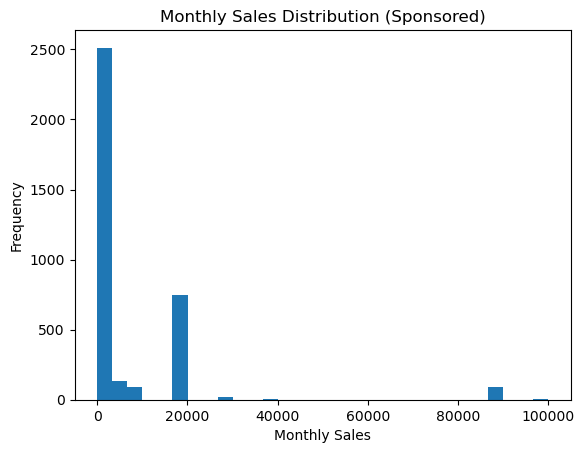

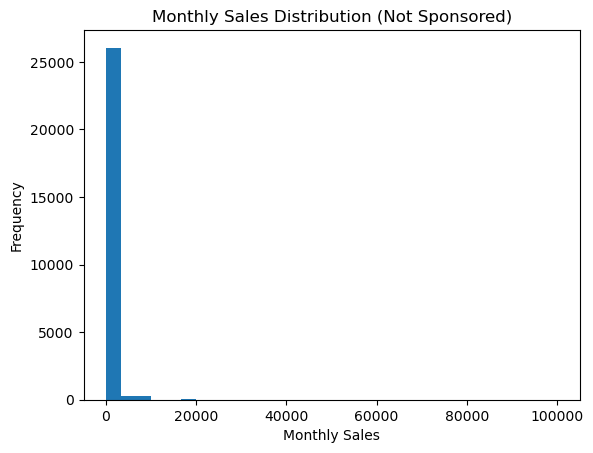

In [119]:
plt.hist(df2[df2["sponsored_label"]=="Sponsored"]["monthly_sales"], bins=30)
plt.title("Monthly Sales Distribution (Sponsored)")
plt.xlabel("Monthly Sales")
plt.ylabel("Frequency")
plt.show()

plt.hist(df2[df2["sponsored_label"]=="Not Sponsored"]["monthly_sales"], bins=30)
plt.title("Monthly Sales Distribution (Not Sponsored)")
plt.xlabel("Monthly Sales")
plt.ylabel("Frequency")
plt.show()

In [120]:
print("This histograms show that monthly sales appear right skewed for both sponsored and non-sponsored products. However, since the sample size is Very large(30,000),the large sample size allows us to rely on the Central Limit Theorem, therefore allows the use of an independent samples t-test.")

This histograms show that monthly sales appear right skewed for both sponsored and non-sponsored products. However, since the sample size is Very large(30,000),the large sample size allows us to rely on the Central Limit Theorem, therefore allows the use of an independent samples t-test.


In [121]:
spon = df2[df2["sponsored_label"]=="Sponsored"]["monthly_sales"]
not_spon = df2[df2["sponsored_label"]=="Not Sponsored"]["monthly_sales"]

t1, p1 = stats.ttest_ind(spon, not_spon, equal_var=False, nan_policy="omit")

print("T-Test 1: Sponsored vs Not Sponsored")
print("Mean Sponsored:", spon.mean())
print("Mean Not Sponsored:", not_spon.mean())
print("t-statistic:", t1)
print("p-value:", p1)

T-Test 1: Sponsored vs Not Sponsored
Mean Sponsored: 7683.828841344818
Mean Not Sponsored: 499.1494235607796
t-statistic: 26.93047705990353
p-value: 8.92212738462825e-146


In [122]:
spon = df2[df2["sponsored_label"]=="Sponsored"]["monthly_sales"]
not_spon = df2[df2["sponsored_label"]=="Not Sponsored"]["monthly_sales"]

print("n Sponsored:", len(spon))
print("n Not Sponsored:", len(not_spon))

t1, p1 = stats.ttest_ind(spon, not_spon, equal_var=False, nan_policy="omit")

print("Mean Sponsored:", spon.mean())
print("Mean Not Sponsored:", not_spon.mean())
print("t-statistic:", t1)
print("p-value:", p1)

n Sponsored: 3599
n Not Sponsored: 26629
Mean Sponsored: 7683.828841344818
Mean Not Sponsored: 499.1494235607796
t-statistic: 26.93047705990353
p-value: 8.92212738462825e-146


In [123]:
print("The independent samples t-test comparing monthly sales between sponsored and non-sponsored products resulted in a p-value of 8.92 × 10⁻¹⁴⁶. Since this p-value is far below 0.05, we reject the null hypothesis.")

The independent samples t-test comparing monthly sales between sponsored and non-sponsored products resulted in a p-value of 8.92 × 10⁻¹⁴⁶. Since this p-value is far below 0.05, we reject the null hypothesis.


In [124]:
hi = df2[df2["discount_group"]=="High Discount"]["monthly_sales"]
lo = df2[df2["discount_group"]=="Low Discount"]["monthly_sales"]

print("n High Discount:", len(hi))
print("n Low Discount:", len(lo))

t2, p2 = stats.ttest_ind(hi, lo, equal_var=False, nan_policy="omit")

print("Mean High Discount:", hi.mean())
print("Mean Low Discount:", lo.mean())
print("t-statistic:", t2)
print("p-value:", p2)

n High Discount: 10647
n Low Discount: 19581
Mean High Discount: 2132.483328637175
Mean Low Discount: 931.5867422501404
t-statistic: 12.393080011155867
p-value: 4.588203821573359e-35


In [129]:
print("The independent samples t-test comparing monthly sales between high-discount and low-discount products resulted in a p-value of 4.59 × 10⁻³⁵. Since this p-value is well below 0.05, we reject the null hypothesis.")

The independent samples t-test comparing monthly sales between high-discount and low-discount products resulted in a p-value of 4.59 × 10⁻³⁵. Since this p-value is well below 0.05, we reject the null hypothesis.


In [130]:
ct1 = pd.crosstab(df2["sponsored_label"], df2["high_sales"])
ct1

high_sales,High Sales,Low Sales
sponsored_label,,
Not Sponsored,8615,18014
Sponsored,2816,783


In [131]:
chi1, pchi1, dof1, expected1 = stats.chi2_contingency(ct1)

print("Chi-Square Test 1: Sponsorship vs High Sales")
print("Chi-square statistic:", chi1)
print("p-value:", pchi1)
print("Degrees of freedom:", dof1)

Chi-Square Test 1: Sponsorship vs High Sales
Chi-square statistic: 2837.585572571408
p-value: 0.0
Degrees of freedom: 1


In [134]:
print("The chi-square test of independence examining sponsorship status and high sales resulted in a p-value of less than 0.001. Since this p-value is well below 0.05, we reject the null hypothesis.")

The chi-square test of independence examining sponsorship status and high sales resulted in a p-value of less than 0.001. Since this p-value is well below 0.05, we reject the null hypothesis.


In [135]:
ct2 = pd.crosstab(df2["category"], df2["high_sales"])
ct2.head(10)

high_sales,High Sales,Low Sales
category,,
Cameras,686,1804
Chargers & Cables,758,786
Gaming,78,370
Headphones,220,766
Laptops,1563,4475
Networking,95,731
Other Electronics,1884,3411
Phones,2777,2331
Power & Batteries,1892,791


In [136]:
chi2, pchi2, dof2, expected2 = stats.chi2_contingency(ct2)

print("Chi-Square Test 2: Category vs High Sales")
print("Chi-square statistic:", chi2)
print("p-value:", pchi2)
print("Degrees of freedom:", dof2)

Chi-Square Test 2: Category vs High Sales
Chi-square statistic: 3127.5243407754556
p-value: 0.0
Degrees of freedom: 14


In [138]:
print("The chi-square test examining product category and high sales status resulted in a p-value of less than 0.001. Since this p-value is well below 0.05, we reject the null hypothesis. Indicating product category and high sales status are statistically associated.")

The chi-square test examining product category and high sales status resulted in a p-value of less than 0.001. Since this p-value is well below 0.05, we reject the null hypothesis. Indicating product category and high sales status are statistically associated.


In [139]:
print("Linear Regression Model 1")
print("Dependent Variable: monthly_sales")
print("Main Independent Variable: total_reviews")
print("Control Variables: discounted_price and discount_percentage")

Linear Regression Model 1
Dependent Variable: monthly_sales
Main Independent Variable: total_reviews
Control Variables: discounted_price and discount_percentage


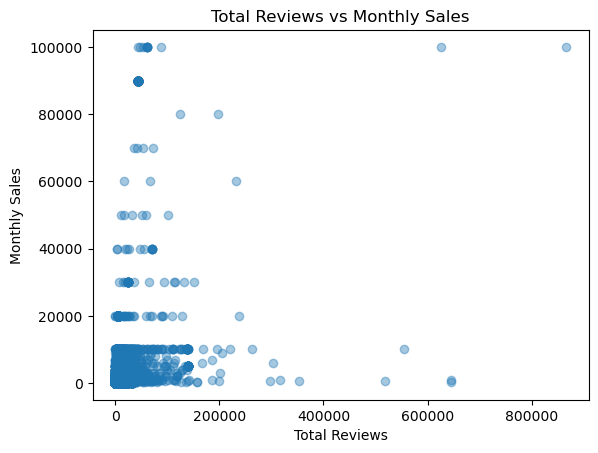

In [140]:
plt.scatter(df2["total_reviews"], df2["monthly_sales"], alpha=0.4)
plt.title("Total Reviews vs Monthly Sales")
plt.xlabel("Total Reviews")
plt.ylabel("Monthly Sales")
plt.show()

In [142]:
print("The scatterplot shows a positive relationship between total reviews and monthly sales. Products with a higher number of reviews tend to have higher monthly sales. Although there is noticeable variation and clustering at lower sales levels.")

The scatterplot shows a positive relationship between total reviews and monthly sales. Products with a higher number of reviews tend to have higher monthly sales. Although there is noticeable variation and clustering at lower sales levels.


In [143]:
model1 = smf.ols("monthly_sales ~ total_reviews + discounted_price + discount_percentage", data=df2).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          monthly_sales   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     1063.
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:11:17   Log-Likelihood:            -3.0665e+05
No. Observations:               30228   AIC:                         6.133e+05
Df Residuals:                   30224   BIC:                         6.134e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1025.4360    

In [144]:
print("The coefficient for total_reviews is positive (0.1279), meaning that as the number of reviews increases, monthly sales increase, holding other variables constant.")
print("The coefficient for discounted_price is negative (−1.6771), meaning that higher prices are associated with lower monthly sales.")
print("The coefficient for discount_percentage is positive (15.2815), meaning higher discounts are associated with higher monthly sales.")
print("All p-values are less than 0.05, which means the relationships are statistically significant. Therefore, we reject the null hypothesis and conclude that these variables significantly affect monthly sales.")

The coefficient for total_reviews is positive (0.1279), meaning that as the number of reviews increases, monthly sales increase, holding other variables constant.
The coefficient for discounted_price is negative (−1.6771), meaning that higher prices are associated with lower monthly sales.
The coefficient for discount_percentage is positive (15.2815), meaning higher discounts are associated with higher monthly sales.
All p-values are less than 0.05, which means the relationships are statistically significant. Therefore, we reject the null hypothesis and conclude that these variables significantly affect monthly sales.


In [145]:
print("The R² value is 0.095, which means that approximately 9.5% of the variation in monthly_sales is explained by total_reviews, discounted_price, and discount_percentage. This suggests that although the model is statistically significant,a large portion of the variation in sales is influenced by factors not included in the model.")

The R² value is 0.095, which means that approximately 9.5% of the variation in monthly_sales is explained by total_reviews, discounted_price, and discount_percentage. This suggests that although the model is statistically significant,a large portion of the variation in sales is influenced by factors not included in the model.


In [146]:
print("Linear Regression Model 2")
print("Dependent Variable: monthly_sales")
print("Main Independent Variable: discount_percentage")
print("Control Variables: total_reviews and discounted_price")

Linear Regression Model 2
Dependent Variable: monthly_sales
Main Independent Variable: discount_percentage
Control Variables: total_reviews and discounted_price


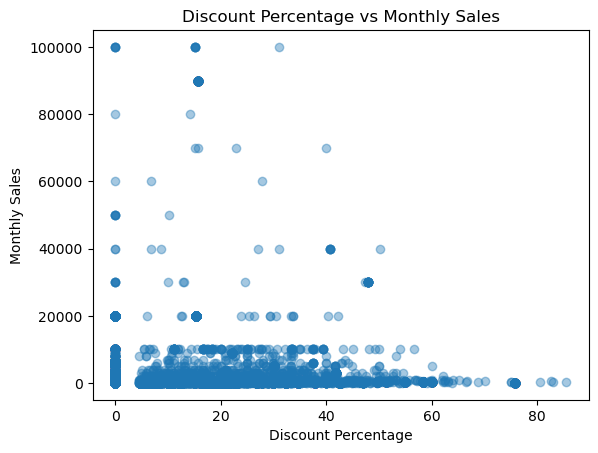

In [147]:
plt.scatter(df2["discount_percentage"], df2["monthly_sales"], alpha=0.4)
plt.title("Discount Percentage vs Monthly Sales")
plt.xlabel("Discount Percentage")
plt.ylabel("Monthly Sales")
plt.show()

In [148]:
print("The scatterplot shows a slight positive relationship between discount percentage and monthly sales. As discount percentage increases, monthly sales tend to increase, but the relationship appears weak because the points are widely spread out.")

The scatterplot shows a slight positive relationship between discount percentage and monthly sales. As discount percentage increases, monthly sales tend to increase, but the relationship appears weak because the points are widely spread out.


In [149]:
model2 = smf.ols("monthly_sales ~ discount_percentage + total_reviews + discounted_price", data=df2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:          monthly_sales   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     1063.
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:11:24   Log-Likelihood:            -3.0665e+05
No. Observations:               30228   AIC:                         6.133e+05
Df Residuals:                   30224   BIC:                         6.134e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1025.4360    

In [150]:
print("The coefficient for discount_percentage is positive (15.2815), meaning that as discount percentage increases, monthly sales increase, holding other variables constant.")
print("The coefficient for total_reviews is positive (0.1279), meaning more reviews are associated with higher sales.")
print("The coefficient for discounted_price is negative (−1.6771), meaning higher prices are associated with lower sales.")
print("All p-values are below 0.05, which means these relationships are statistically significant. Therefore, we reject the null hypothesis and conclude that discount percentage significantly affects monthly sales.")

The coefficient for discount_percentage is positive (15.2815), meaning that as discount percentage increases, monthly sales increase, holding other variables constant.
The coefficient for total_reviews is positive (0.1279), meaning more reviews are associated with higher sales.
The coefficient for discounted_price is negative (−1.6771), meaning higher prices are associated with lower sales.
All p-values are below 0.05, which means these relationships are statistically significant. Therefore, we reject the null hypothesis and conclude that discount percentage significantly affects monthly sales.


In [151]:
print("The R² value is 0.095, meaning the model explains about 9.5% of the variation in monthly sales. This shows that the model explains some of the changes in sales, but most is due to non associated factors")

The R² value is 0.095, meaning the model explains about 9.5% of the variation in monthly sales. This shows that the model explains some of the changes in sales, but most is due to non associated factors
